## **LOAD LIBRARIES & DATASET**

### Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

### Dataset

Download from https://www.kaggle.com/datasets/canggih/jog-description-and-salary-in-indonesia

In [2]:
salarydf = pd.read_csv("all.csv", sep='|')
salarydf.head(5)

,id,job_title,location,salary_currency,career_level,experience_level,education_level,employment_type,job_function,job_benefits,company_process_time,company_size,company_industry,job_description,salary
0,1,Facility Maintenance & Smart Warehouse Manager,Bandung,IDR,Manajer/Asisten Manajer,5 tahun,"Sertifikat Professional, D3 (Diploma), D4 (Dip...",Penuh Waktu,"Manufaktur,Pemeliharaan",NaN,NaN,NaN,NaN,Deskripsi PekerjaanRequirements :D3/SI from re...,NaN
1,2,Procurement Department Head,Jakarta Raya,IDR,Manajer/Asisten Manajer,5 tahun,"Sarjana (S1), Diploma Pascasarjana, Gelar Prof...",Penuh Waktu,"Manufaktur,Pembelian/Manajemen Material",NaN,25 days,51 - 200 pekerja,Manajemen/Konsulting HR,Job Role: 1. Responsible for material availabi...,NaN
2,3,SALES ADMIN,Jakarta Barat,IDR,Supervisor/Koordinator,4 tahun,Sarjana (S1),Penuh Waktu,"Penjualan / Pemasaran,Penjualan Ritel","Waktu regular, Senin - Jumat;Bisnis (contoh: K...",30 days,51 - 200 pekerja,Umum & Grosir,Internal Sales & AdminJob Description :We are ...,NaN
3,4,City Operation Lead Shopee Express (Cirebon),Cirebon,IDR,Supervisor/Koordinator,5 tahun,"Sarjana (S1), Diploma Pascasarjana, Gelar Prof...",Penuh Waktu,"Pelayanan,Logistik/Rantai Pasokan","Tip;Waktu regular, Senin - Jumat;Kasual (conto...",21 days,2001 - 5000 pekerja,Retail/Merchandise,Job Description:Responsible for HSE implementa...,NaN
4,5,Japanese Interpreter,Bekasi,IDR,Pegawai (non-manajemen & non-supervisor),2 tahun,"Sertifikat Professional, D3 (Diploma), D4 (Dip...",Penuh Waktu,"Lainnya,Jurnalis/Editor",NaN,23 days,201 - 500 pekerja,Manajemen/Konsulting HR,Overview: Our clients is manufacture for autom...,NaN


__Meta Data__ :

| Column               | Description                                                                |
| -------------------- | -------------------------------------------------------------------------- |
| `id`                 | Unique identifier for each data record.                                    |
| `job_title`          | Name or title of the job.                                                  |
| `location`           | Location of the company or job.                                            |
| `salary_currency`    | Currency used for the salary.                                              |
| `career_level`       | Career level of the position, such as staff, manager, director, or CEO.    |
| `experience_level`   | Level of work experience required from applicants.                         |
| `education_level`    | Minimum education level required from applicants.                          |
| `employment_type`    | Type of employment, such as full-time, part-time, contract, or internship. |
| `job_function`       | Functional category of the job.                                            |
| `job_benefits`       | Benefits provided by the company.                                          |
| `companyprocesstime` | Average time taken by the company to respond to applicants.                |
| `company_size`       | Number of employees in the company.                                        |
| `company_industry`   | Industry or business sector of the company.                                |
| `job_description`    | Description of the job responsibilities and requirements.                  |
| `salary`             | Monthly salary offered by the company, based on data from March 2022.      |

__Explanation__:

| Section               | Description                                                                                                                                                                                                                                                                                                                                                                                                                      |
| --------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Problem Statement** | Many people want to find jobs based on the offered salary range. In this dataset, each record is classified into one of three salary classes based on the Provincial Minimum Wage or **UMP** of the job location: **Rendah** — salary less than or equal to the province's UMP; **Sedang** — salary greater than the UMP and less than or equal to twice the UMP; and **Tinggi** — salary greater than twice the province's UMP. |
| **Goal**              | Predict the salary class of a job based on its field of work, particularly the `career_level`, `job_function`, and `location` variables.                                                                                                                                                                                                                                                                                         |
| **Target Output**     | Predicted salary-level class: **Rendah**, **Sedang**, or **Tinggi**.                                                                                                                                                                                                                                                                                                                                                             |

## **DATA CLEANING**

In [3]:
salarydf = salarydf[salarydf['salary'].notna()]

__Explanation__:

Since our target variable is `salary`, we will remove all records that have missing salary value.

### Detect Outliers

{'whiskers': [<matplotlib.lines.Line2D at 0x20672a99290>,
 'caps': [<matplotlib.lines.Line2D at 0x20672a9a950>,
 'boxes': [<matplotlib.lines.Line2D at 0x20672a985d0>],
 'medians': [<matplotlib.lines.Line2D at 0x20672a9bf10>],
 'fliers': [<matplotlib.lines.Line2D at 0x20672aa4950>],
 'means': []}

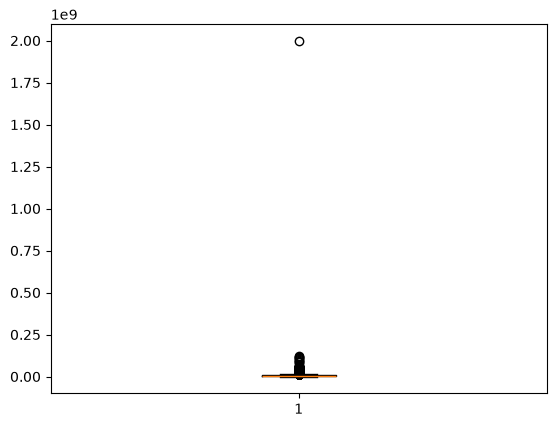

In [4]:
plt.boxplot(salarydf['salary'])

In [5]:
salarydf = salarydf[salarydf['salary'] < max(salarydf['salary'])]
salarydf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9351 entries, 5 to 34745
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9351 non-null   int64  
 1   job_title             9351 non-null   object 
 2   location              9351 non-null   object 
 3   salary_currency       9351 non-null   object 
 4   career_level          9351 non-null   object 
 5   experience_level      8569 non-null   object 
 6   education_level       9351 non-null   object 
 7   employment_type       9351 non-null   object 
 8   job_function          9351 non-null   object 
 9   job_benefits          7069 non-null   object 
 10  company_process_time  6157 non-null   object 
 11  company_size          7927 non-null   object 
 12  company_industry      9059 non-null   object 
 13  job_description       9351 non-null   object 
 14  salary                9351 non-null   float64
dtypes: float64(1), int64(1), 

__EXPLANATION__:

We remove the outliers by excluding record with maximum value of salary.

### Imputation

In this step, we will plug in the missing values ​​in the predictors (`experience_level`, `job_benefit`, `company_process_time`, `company_size`, `company_industry`) **with mode values**, as they are **categorical data**. Excluding the records will remove too much information.

#### 1. Impute Experience Level

In the `experience_level` variable, there are 782 missing values to impute.

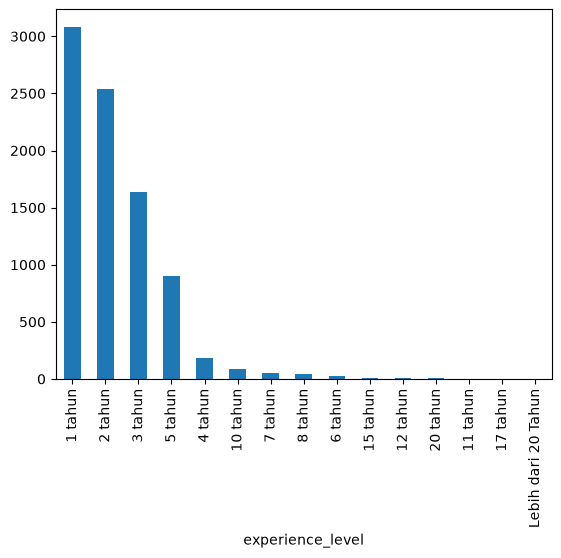

In [6]:
exp =  salarydf['experience_level'].value_counts()
exp.plot(kind = 'bar')
plt.show()

__Explanation__:

The mode of this variable is '1 year', so the missing value will be replaced by '1 year'.

In [7]:
salarydf['experience_level'] = salarydf['experience_level'].fillna(salarydf['experience_level'].mode()[0])
salarydf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9351 entries, 5 to 34745
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9351 non-null   int64  
 1   job_title             9351 non-null   object 
 2   location              9351 non-null   object 
 3   salary_currency       9351 non-null   object 
 4   career_level          9351 non-null   object 
 5   experience_level      9351 non-null   object 
 6   education_level       9351 non-null   object 
 7   employment_type       9351 non-null   object 
 8   job_function          9351 non-null   object 
 9   job_benefits          7069 non-null   object 
 10  company_process_time  6157 non-null   object 
 11  company_size          7927 non-null   object 
 12  company_industry      9059 non-null   object 
 13  job_description       9351 non-null   object 
 14  salary                9351 non-null   float64
dtypes: float64(1), int64(1), 

__Explanation__:

After inputing missing values with mode, there are no longer missing values in `experience_level` variable, which can be seen from the number of non-null data (9351 records). Next, we will imput 4 other variables that have missing values (`job_benefits`, `company_process_time`, `company_size`, and `company_industry`).

#### 2. Imputate Job Benefits, Company Process Time, Company Size, and Company Industry

We will also impute these variables with their mode value.

In [8]:
salarydf['job_benefits'] = salarydf['job_benefits'].fillna(salarydf['job_benefits'].mode()[0])
salarydf['company_process_time'] = salarydf['company_process_time'].fillna(salarydf['company_process_time'].mode()[0])
salarydf['company_size'] = salarydf['company_size'].fillna(salarydf['company_size'].mode()[0])
salarydf['company_industry'] = salarydf['company_industry'].fillna(salarydf['company_industry'].mode()[0])

In [9]:
salarydf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9351 entries, 5 to 34745
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9351 non-null   int64  
 1   job_title             9351 non-null   object 
 2   location              9351 non-null   object 
 3   salary_currency       9351 non-null   object 
 4   career_level          9351 non-null   object 
 5   experience_level      9351 non-null   object 
 6   education_level       9351 non-null   object 
 7   employment_type       9351 non-null   object 
 8   job_function          9351 non-null   object 
 9   job_benefits          9351 non-null   object 
 10  company_process_time  9351 non-null   object 
 11  company_size          9351 non-null   object 
 12  company_industry      9351 non-null   object 
 13  job_description       9351 non-null   object 
 14  salary                9351 non-null   float64
dtypes: float64(1), int64(1), 

__Explanation__:

All missing values are cleaned. We can proceed to the next preparation process.

## **DATA TRANSFORMATION**

### Convert salary in currency USD to IDR

Currently there are 2 types of salary currency (USD and IDR), so we need to standardize the salary values. Since we are working with a dataset representing Indonesia, we will convert the salary value of all records with "USD" currency into "IDR" currency.

In [10]:
salarydf['salary_currency'].unique()

array(['IDR', 'USD'], dtype=object)

In [11]:
for x in salarydf.index :
    if (salarydf['salary_currency'][x]) == 'USD' : 
        salarydf['salary'][x] = salarydf['salary'][x] * 14327
        salarydf['salary_currency'][x] = 'IDR'
        # IDR-USD value per 13 March 2022

### Tidy Up Each Variables

We will convert the data type to integer because days and years are numerical values. But due to characters behind the number of days and years, the data type is assumed as object. Removing the characters ('days', 'tahun') after the integer value will allow conversion into integer.

In [12]:
salarydf['experience_level'] = salarydf['experience_level'].str.replace(' tahun', '', regex = True)
salarydf['company_process_time'] = salarydf['company_process_time'].str.replace(' days', '', regex = True)
salarydf['company_process_time'] = salarydf['company_process_time'].str.replace(' day', '', regex = True)

In [13]:
salarydf['experience_level'].unique()

array(['1', '3', '2', '5', '4', '10', '6', '8', '7', '15', '12', '11',
       '17', '20', 'Lebih dari 20 Tahun'], dtype=object)

Because there is only 1 record with `experience_level` of 'Lebih dari 20 Tahun', we will remove it to allow integer data type conversion on variable `experience_level`.

In [14]:
index_exp = salarydf[(salarydf['experience_level'] == 'Lebih dari 20 Tahun')].index
salarydf.drop(index_exp , inplace=True)

In [15]:
salarydf['experience_level'] = salarydf['experience_level'].astype('int')
salarydf['company_process_time'] = salarydf['company_process_time'].astype('int')

salarydf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9350 entries, 5 to 34745
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9350 non-null   int64  
 1   job_title             9350 non-null   object 
 2   location              9350 non-null   object 
 3   salary_currency       9350 non-null   object 
 4   career_level          9350 non-null   object 
 5   experience_level      9350 non-null   int32  
 6   education_level       9350 non-null   object 
 7   employment_type       9350 non-null   object 
 8   job_function          9350 non-null   object 
 9   job_benefits          9350 non-null   object 
 10  company_process_time  9350 non-null   int32  
 11  company_size          9350 non-null   object 
 12  company_industry      9350 non-null   object 
 13  job_description       9350 non-null   object 
 14  salary                9350 non-null   float64
dtypes: float64(1), int32(2), 

Data type successfully changed into Integer.

### Check Duplicate Value

In [16]:
print(salarydf[salarydf.duplicated()])

Empty DataFrame
Columns: [id, job_title, location, salary_currency, career_level, experience_level, education_level, employment_type, job_function, job_benefits, company_process_time, company_size, company_industry, job_description, salary]
Index: []


Our records are all unique.

### Check Dataset Distribution

In [17]:
salarydf.describe().T

,count,mean,std,min,25%,50%,75%,max
id,9350.0,2.144322e+04,1.110719e+04,6.0,11865.25,23321.0,32407.75,34746.0
experience_level,9350.0,2.265989e+00,1.704050e+00,1.0,1.00,2.0,3.00,20.0
company_process_time,9350.0,2.379198e+01,7.803326e+00,1.0,21.00,28.0,29.00,30.0
salary,9350.0,7.148199e+06,6.064939e+06,10.0,4250000.00,5500000.0,8000000.00,120000000.0


In [18]:
salarydf[['experience_level', 'company_process_time', 'salary']].skew()

experience_level        2.811288
company_process_time   -1.530456
salary                  6.378620
dtype: float64

__Explanation__:
- `experience_level` is highly skewed to the right (positive skew), which means the distribution is asymmetrical. This can also be seen from the mean value (2.265...) which is greater than the median value (2.0). 
- `company_process_time` is highly skewed to the left (negative skew), which means the distribution is asymmetrical. This can also be seen from the mean value (2.37...) which is smaller than the median value (28).
- `salary` is also highly skewed to the right (positive skew), which means the distribution is asymmetrical. This can also be seen from the mean value (7148199) which is greater than the median value (5500000). 

### Grouping Location

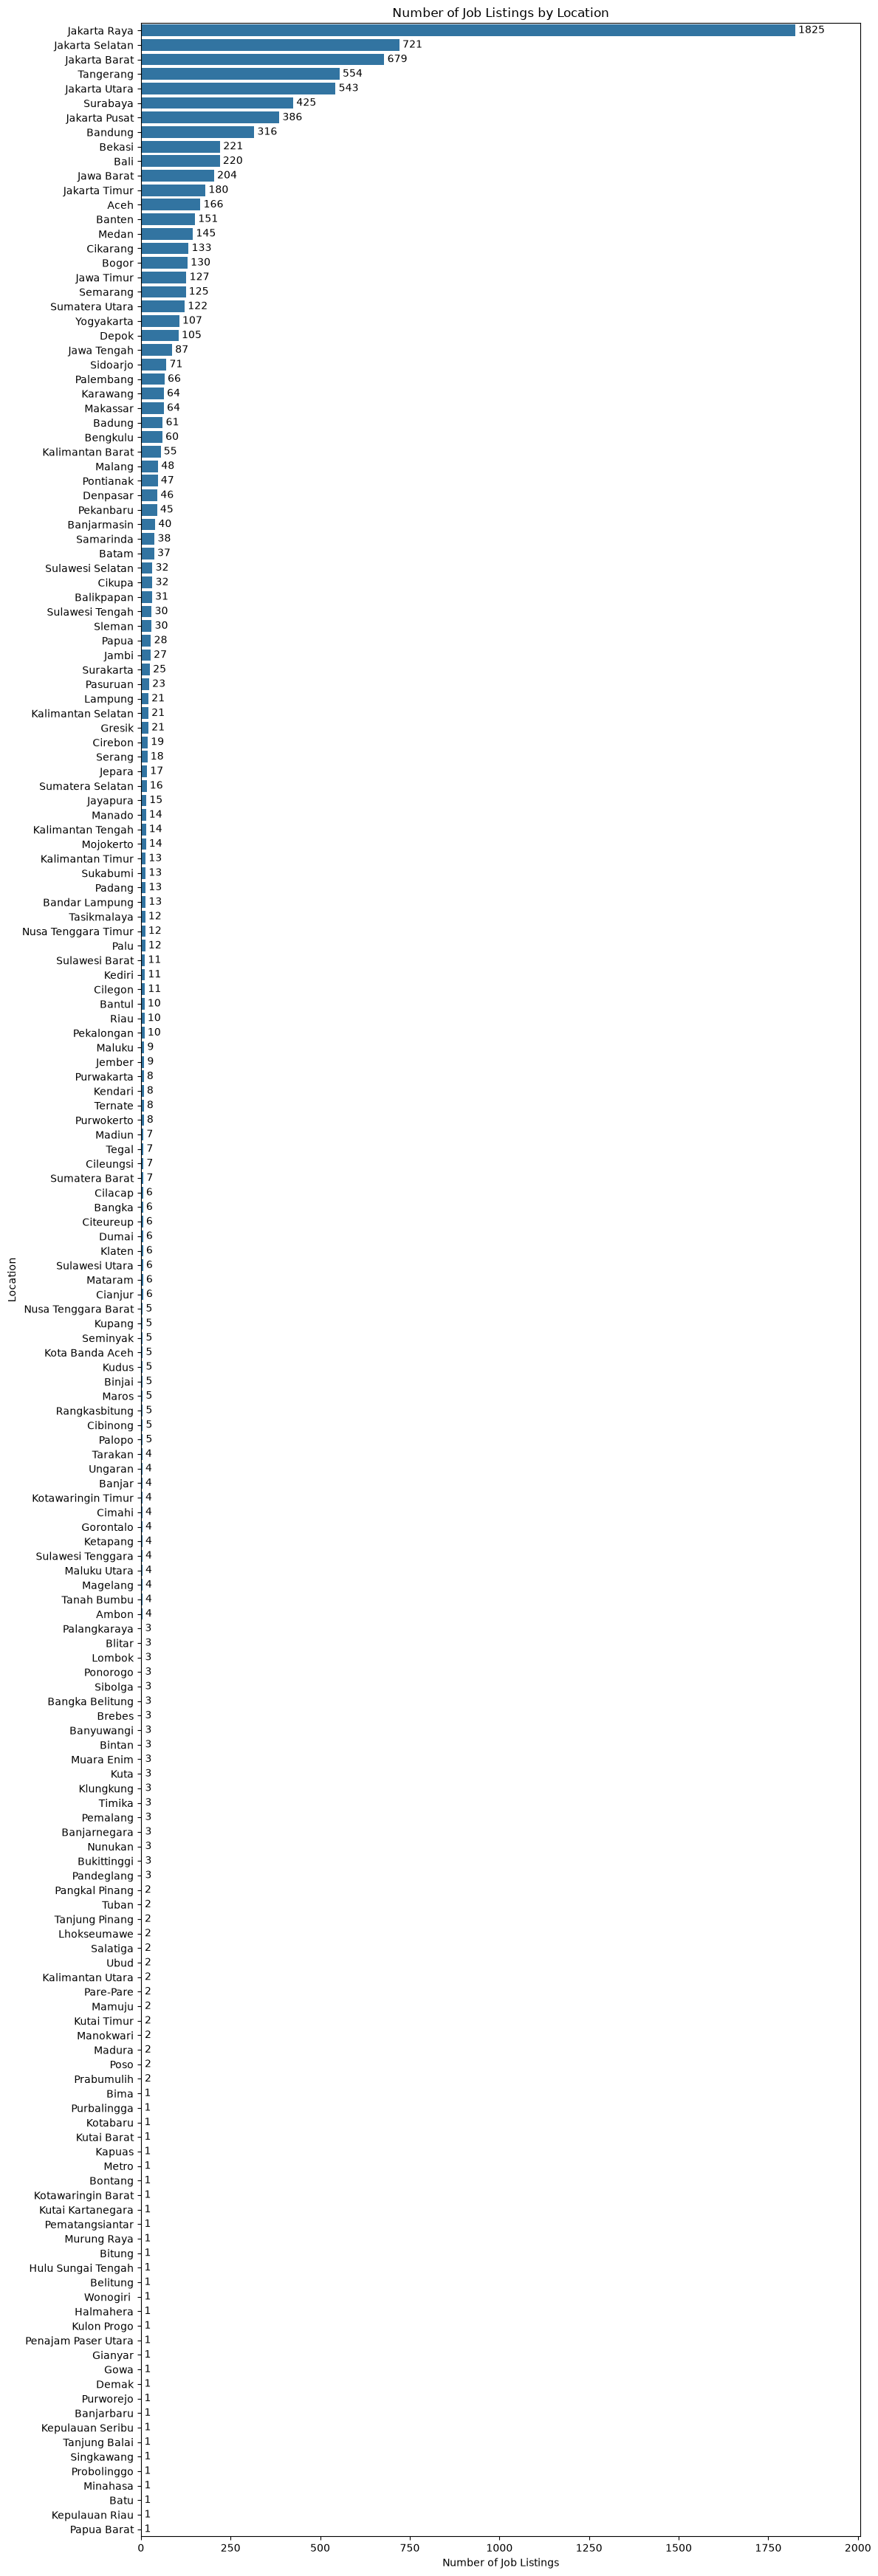

In [19]:
location_order = salarydf["location"].value_counts().index

plt.figure(figsize=(12, 35))
ax = sns.countplot(data=salarydf, y="location", order=location_order)
ax.bar_label(ax.containers[0], padding=3, fmt="%d") # Add count labels at the edge of each bar
plt.xlabel("Number of Job Listings")
plt.ylabel("Location")
plt.title("Number of Job Listings by Location")
plt.xlim(0, salarydf["location"].value_counts().max() * 1.1) # Add space so labels are not cut off
plt.tight_layout()
plt.show()

__Explanation__:
- The `location` values represent cities in Indonesia.
- We decided to group those cities to their respective province to align with our model's purpose: Predicting province minimum wage level.
- Based on current region division per 2022, Indonesia has 34 provinces.

In [20]:
for x in salarydf.index :
    if (salarydf['location'][x] == 'Bali') | (salarydf['location'][x] == 'Badung') | (salarydf['location'][x] == 'Seminyak') | (salarydf['location'][x] == 'Denpasar') | (salarydf['location'][x] == 'Klungkung') | (salarydf['location'][x] == 'Kuta') | (salarydf['location'][x] == 'Gianyar') | (salarydf['location'][x] == 'Ubud'): 
        salarydf['location'][x] = 'Bali'
    elif (salarydf['location'][x] == 'Banten') | (salarydf['location'][x] == 'Tangerang') | (salarydf['location'][x] == 'Cilegon') | (salarydf['location'][x] == 'Rangkasbitung') | (salarydf['location'][x] == 'Serang') | (salarydf['location'][x] == 'Cikupa') | (salarydf['location'][x] == 'Pandeglang'): 
        salarydf['location'][x] = 'Banten'
    elif (salarydf['location'][x] == 'Bengkulu'): 
        salarydf['location'][x] = 'Bengkulu'
    elif (salarydf['location'][x] == 'Yogyakarta') | (salarydf['location'][x] == 'Sleman') | (salarydf['location'][x] == 'Bantul'):
        salarydf['location'][x] = 'DIY'
    elif (salarydf['location'][x] == 'Jakarta Pusat') | (salarydf['location'][x] == 'Jakarta Timur') | (salarydf['location'][x] == 'Jakarta Barat') | (salarydf['location'][x] == 'Jakarta Utara') | (salarydf['location'][x] == 'Jakarta Raya') | (salarydf['location'][x] == 'Jakarta Selatan') | (salarydf['location'][x] == 'Kepulauan Seribu'):
        salarydf['location'][x] = 'DKI Jakarta'
    elif (salarydf['location'][x] == 'Gorontalo'): 
        salarydf['location'][x] = 'Gorontalo'
    elif (salarydf['location'][x] == 'Jambi'): 
        salarydf['location'][x] = 'Jambi' 
    elif (salarydf['location'][x] == 'Jawa Barat') | (salarydf['location'][x] == 'Cikarang') | (salarydf['location'][x] == 'Bekasi') | (salarydf['location'][x] == 'Bandung') | (salarydf['location'][x] == 'Cianjur') | (salarydf['location'][x] == 'Cirebon') | (salarydf['location'][x] == 'Bogor') | (salarydf['location'][x] == 'Depok') | (salarydf['location'][x] == 'Karawang') | (salarydf['location'][x] == 'Sukabumi') | (salarydf['location'][x] == 'Purwakarta') | (salarydf['location'][x] == 'Cibinong') | (salarydf['location'][x] == 'Banjar') | (salarydf['location'][x] == 'Cimahi') | (salarydf['location'][x] == 'Citeureup') | (salarydf['location'][x] == 'Tasikmalaya') | (salarydf['location'][x] == 'Cileungsi'):  
        salarydf['location'][x] = 'Jawa Barat'
    elif (salarydf['location'][x] == 'Semarang') | (salarydf['location'][x] == 'Banjarnegara') | (salarydf['location'][x] == 'Purwokerto') | (salarydf['location'][x] == 'Jawa Tengah') | (salarydf['location'][x] == 'Tegal') | (salarydf['location'][x] == 'Surakarta') | (salarydf['location'][x] == 'Magelang') | (salarydf['location'][x] == 'Jepara') | (salarydf['location'][x] == 'Pekalongan') | (salarydf['location'][x] == 'Cilacap') | (salarydf['location'][x] == 'Pemalang') | (salarydf['location'][x] == 'Klaten') | (salarydf['location'][x] == 'Kulon Progo') | (salarydf['location'][x] == 'Brebes') | (salarydf['location'][x] == 'Demak') | (salarydf['location'][x] == 'Purworejo') | (salarydf['location'][x] == 'Kudus') | (salarydf['location'][x] == 'Salatiga') | (salarydf['location'][x] == 'Ungaran') | (salarydf['location'][x] == 'Wonogiri ') | (salarydf['location'][x] == 'Purbalingga'):  
        salarydf['location'][x] = 'Jawa Tengah'  
    elif (salarydf['location'][x] == 'Surabaya') | (salarydf['location'][x] == 'Sidoarjo') | (salarydf['location'][x] == 'Jawa Timur') | (salarydf['location'][x] == 'Pasuruan') | (salarydf['location'][x] == 'Kediri') | (salarydf['location'][x] == 'Gresik') | (salarydf['location'][x] == 'Mojokerto') | (salarydf['location'][x] == 'Malang') | (salarydf['location'][x] == 'Madiun') | (salarydf['location'][x] == 'Jember') | (salarydf['location'][x] == 'Banyuwangi') | (salarydf['location'][x] == 'Madura') | (salarydf['location'][x] == 'Tuban') | (salarydf['location'][x] == 'Probolinggo') | (salarydf['location'][x] == 'Blitar') | (salarydf['location'][x] == 'Ponorogo') | (salarydf['location'][x] == 'Batu'):  
        salarydf['location'][x] = 'Jawa Timur' 
    elif (salarydf['location'][x] == 'Kalimantan Barat') | (salarydf['location'][x] == 'Pontianak') | (salarydf['location'][x] == 'Ketapang') | (salarydf['location'][x] == 'Singkawang'):  
        salarydf['location'][x] = 'Kalimantan Barat'     
    elif (salarydf['location'][x] == 'Banjarmasin') | (salarydf['location'][x] == 'Tanah Bumbu') | (salarydf['location'][x] == 'Kalimatan Selatan') | (salarydf['location'][x] == 'Banjarbaru') | (salarydf['location'][x] == 'Kotabaru') | (salarydf['location'][x] == 'Hulu Sungai Tengah'):  
        salarydf['location'][x] = 'Kalimantan Selatan'
    elif (salarydf['location'][x] == 'Kapuas') | (salarydf['location'][x] == 'Kotawaringin Timur') | (salarydf['location'][x] == 'Palangkaraya') | (salarydf['location'][x] == 'Murung Raya') | (salarydf['location'][x] == 'Kotawaringin Barat'):  
        salarydf['location'][x] = 'Kalimantan Tengah'
    elif (salarydf['location'][x] == 'Balikpapan') | (salarydf['location'][x] == 'Samarinda') | (salarydf['location'][x] == 'Kalimantan Timur') | (salarydf['location'][x] == '') | (salarydf['location'][x] == 'Kutai Kartanegara') | (salarydf['location'][x] == 'Bontang') | (salarydf['location'][x] == 'Penajam Paser Utara') | (salarydf['location'][x] == 'Kutai Timur') | (salarydf['location'][x] == 'Kutai Kartanegara') | (salarydf['location'][x] == 'Bontang') | (salarydf['location'][x] == 'Kutai Barat'):  
        salarydf['location'][x] = 'Kalimantan Timur'
    elif (salarydf['location'][x] == 'Kalimantan Utara') | (salarydf['location'][x] == 'Nunukan') | (salarydf['location'][x] == 'Tarakan'):  
        salarydf['location'][x] = 'Kalimantan Utara'
    elif (salarydf['location'][x] == 'Batam') | (salarydf['location'][x] == 'Tanjung Pinang') | (salarydf['location'][x] == 'Kepulauan Riau'):  
        salarydf['location'][x] = 'Kepulauan Riau'  
    elif (salarydf['location'][x] == 'Bangka') | (salarydf['location'][x] == 'Belitung') | (salarydf['location'][x] == 'Bintan') | (salarydf['location'][x] == 'Bangka Belitung') | (salarydf['location'][x] == 'Pangkal Pinang'):  
        salarydf['location'][x] = 'Kepulauan Bangka Belitung'
    elif (salarydf['location'][x] == 'Bandar Lampung') | (salarydf['location'][x] == 'Lampung') | (salarydf['location'][x] == 'Metro'):  
        salarydf['location'][x] = 'Lampung'
    elif (salarydf['location'][x] == 'Ambon') | (salarydf['location'][x] == 'Maluku'):  
        salarydf['location'][x] = 'Maluku'
    elif (salarydf['location'][x] == 'Maluku Utara') | (salarydf['location'][x] == 'Ternate') | (salarydf['location'][x] == 'Halmahera'):  
        salarydf['location'][x] = 'Maluku Utara'
    elif (salarydf['location'][x] == 'Aceh') | (salarydf['location'][x] == 'Lhokseumawe') | (salarydf['location'][x] == 'Kota Banda Aceh'):  
        salarydf['location'][x] = 'NAD'
    elif (salarydf['location'][x] == 'Mataram') | (salarydf['location'][x] == 'Nusa Tenggara Barat') | (salarydf['location'][x] == 'Lombok') | (salarydf['location'][x] == 'Bima'):  
        salarydf['location'][x] = 'NTB'
    elif (salarydf['location'][x] == 'Nusa Tenggara Timur') | (salarydf['location'][x] == 'Kupang'):  
        salarydf['location'][x] = 'NTT'
    elif (salarydf['location'][x] == 'Papua') | (salarydf['location'][x] == 'Jayapura') | (salarydf['location'][x] == 'Timika'):  
        salarydf['location'][x] = 'Papua'
    elif (salarydf['location'][x] == 'Manokwari') | (salarydf['location'][x] == 'Papua Barat'):  
        salarydf['location'][x] = 'Papua Barat'
    elif (salarydf['location'][x] == 'Riau') | (salarydf['location'][x] == 'Pekanbaru') | (salarydf['location'][x] == 'Dumai'):  
        salarydf['location'][x] = 'Riau'
    elif (salarydf['location'][x] == 'Sulawesi Barat') | (salarydf['location'][x] == 'Mamuju'):  
        salarydf['location'][x] = 'Sulawesi Barat'
    elif (salarydf['location'][x] == 'Makassar') | (salarydf['location'][x] == 'Maros') | (salarydf['location'][x] == 'Palopo') | (salarydf['location'][x] == 'Sulawesi Selatan') | (salarydf['location'][x] == 'Gowa') | (salarydf['location'][x] == 'Pare-Pare'):  
        salarydf['location'][x] = 'Sulawesi Selatan'
    elif (salarydf['location'][x] == 'Sulawesi Tengah') | (salarydf['location'][x] == 'Palu') | (salarydf['location'][x] == 'Poso'):  
        salarydf['location'][x] = 'Sulawesi Tengah' 
    elif (salarydf['location'][x] == 'Sulawesi Tenggara') | (salarydf['location'][x] == 'Kendari'):  
        salarydf['location'][x] = 'Sulawesi Tenggara'   
    elif (salarydf['location'][x] == 'Sulawesi Utara') | (salarydf['location'][x] == 'Manado') | (salarydf['location'][x] == 'Minahasa') | (salarydf['location'][x] == 'Bitung'):  
        salarydf['location'][x] = 'Sulawesi Utara'
    elif (salarydf['location'][x] == 'Padang') | (salarydf['location'][x] == 'Sumatera Barat') | (salarydf['location'][x] == 'Bukittinggi'):  
        salarydf['location'][x] = 'Sumatera Barat'
    elif (salarydf['location'][x] == 'Palembang') | (salarydf['location'][x] == 'Sumatera Selatan') | (salarydf['location'][x] == 'Muara Enim') | (salarydf['location'][x] == 'Prabumulih'):  
        salarydf['location'][x] = 'Sumatera Selatan' 
    elif (salarydf['location'][x] == 'Sumatera Utara') | (salarydf['location'][x] == 'Medan') | (salarydf['location'][x] == 'Binjai') | (salarydf['location'][x] == 'Tanjung Balai')  | (salarydf['location'][x] == 'Sibolga')  | (salarydf['location'][x] == 'Pematangsiantar'):  
        salarydf['location'][x] = 'Sumatera Utara'                                

In [21]:
salarydf['location'].unique()

array(['Kalimantan Timur', 'Banten', 'DKI Jakarta', 'Jawa Timur', 'Papua',
       'Maluku Utara', 'Bali', 'Kepulauan Riau', 'Jawa Barat', 'NAD',
       'Sumatera Utara', 'Jawa Tengah', 'Jambi', 'Sumatera Selatan',
       'Riau', 'Sulawesi Tengah', 'Sulawesi Selatan', 'Sumatera Barat',
       'Kalimantan Tengah', 'DIY', 'Kalimantan Selatan', 'Bengkulu',
       'Lampung', 'Kalimantan Barat', 'Kalimantan Utara', 'NTT',
       'Sulawesi Utara', 'Sulawesi Barat', 'NTB', 'Sulawesi Tenggara',
       'Maluku', 'Kepulauan Bangka Belitung', 'Gorontalo', 'Papua Barat'],
      dtype=object)

Now we only have 34 values in `location` variable, representing province instead of cities.

### Group Salary Based On Minimum Wage

Each record will be classified into 3 class, according to their province category:
- 'Rendah' (low income, under that province UMP)
- 'Sedang' (average income, equals too or less than 2 times of that province UMP)
- 'Tinggi' (high income, above 2 times of that province UMP)

The minimum salary of each province (UMP) in Indonesia per 2022:
| No. | Province                  | UMP 2022 |
| --: | ------------------------- | ---------------------------------: |
|   1 | Aceh                      |                       Rp 3.166.460 |
|   2 | Sumatera Utara            |                       Rp 2.522.609 |
|   3 | Sumatera Barat            |                       Rp 2.512.539 |
|   4 | Sumatera Selatan          |                       Rp 3.144.776 |
|   5 | Riau                      |                       Rp 2.938.564 |
|   6 | Kepulauan Riau            |                       Rp 3.050.172 |
|   7 | Jambi                     |                       Rp 2.649.034 |
|   8 | Bengkulu                  |                       Rp 2.238.094 |
|   9 | Lampung                   |                       Rp 2.440.485 |
|  10 | Kepulauan Bangka Belitung |                       Rp 3.264.883 |
|  11 | DKI Jakarta               |                       Rp 4.641.854 |
|  12 | Jawa Barat                |                       Rp 1.841.486 |
|  13 | Jawa Tengah               |                       Rp 1.812.935 |
|  14 | DI Yogyakarta             |                       Rp 1.840.915 |
|  15 | Jawa Timur                |                       Rp 1.891.567 |
|  16 | Banten                    |                       Rp 2.501.202 |
|  17 | Bali                      |                       Rp 2.516.971 |
|  18 | Nusa Tenggara Barat       |                       Rp 2.207.212 |
|  19 | Nusa Tenggara Timur       |                       Rp 1.975.000 |
|  20 | Kalimantan Barat          |                       Rp 2.434.327 |
|  21 | Kalimantan Tengah         |                       Rp 2.922.515 |
|  22 | Kalimantan Selatan        |                       Rp 2.906.472 |
|  23 | Kalimantan Timur          |                       Rp 3.014.496 |
|  24 | Kalimantan Utara          |                       Rp 3.016.738 |
|  25 | Sulawesi Utara            |                       Rp 3.310.723 |
|  26 | Sulawesi Tengah           |                       Rp 2.390.739 |
|  27 | Sulawesi Selatan          |                       Rp 3.165.876 |
|  28 | Sulawesi Tenggara         |                       Rp 2.710.595 |
|  29 | Gorontalo                 |                       Rp 2.800.580 |
|  30 | Sulawesi Barat            |                       Rp 2.678.863 |
|  31 | Maluku                    |                       Rp 2.619.312 |
|  32 | Maluku Utara              |                       Rp 2.862.231 |
|  33 | Papua Barat               |                       Rp 3.200.000 |
|  34 | Papua                     |                       Rp 3.561.932 |

In [22]:
salarydf.groupby('location')['salary'].min()

location
Bali                         1050000.0
Banten                       1125000.0
Bengkulu                     2863085.0
DIY                               10.0
DKI Jakarta                       10.0
Gorontalo                    2185000.0
Jambi                        2160000.0
Jawa Barat                    800000.0
Jawa Tengah                  1500000.0
Jawa Timur                      5300.0
Kalimantan Barat             2160000.0
Kalimantan Selatan           1800000.0
Kalimantan Tengah            2750000.0
Kalimantan Timur             1350000.0
Kalimantan Utara             2880000.0
Kepulauan Bangka Belitung    2875000.0
Kepulauan Riau               2750000.0
Lampung                      2160000.0
Maluku                            15.0
Maluku Utara                 2880000.0
NAD                          3400000.0
NTB                          2875000.0
NTT                          2400000.0
Papua                        2250000.0
Papua Barat                  3750000.0
Riau            

Some of provinces have a very small UMP (< IDR 50.000), which is not plausible for a minimum wage. Therefore, we need to check those data.

In [23]:
idx_salary_50 = []
for x in salarydf.index :
  if (salarydf['salary'][x] < 50000):
    idx_salary_50.append(x)
salarydf.loc[idx_salary_50]

,id,job_title,location,salary_currency,career_level,experience_level,education_level,employment_type,job_function,job_benefits,company_process_time,company_size,company_industry,job_description,salary
2821,2822,Freelance Senior Programmer Aplikasi Pendidikan,DKI Jakarta,IDR,Manajer/Asisten Manajer,4,"Sertifikat Professional, D3 (Diploma), D4 (Dip...",Paruh Waktu,"Komputer/Teknologi Informasi,IT-Perangkat Lunak",Asuransi Gigi;Tunjangan Pendidikan;Asuransi ke...,29,201 - 500 pekerja,"Konsultasi (IT, Ilmu Pengetahuan, Teknis & Tek...",Deskripsi Pekerjaan:Sebuah perusahaan yang sed...,10.0
8623,8624,Staff Marketing,Jawa Timur,IDR,Pegawai (non-manajemen & non-supervisor),1,Tidak terspesifikasi,Kontrak,"Penjualan / Pemasaran,Telesales/Telemarketing",Tip;Bisnis (contoh: Kemeja),29,1- 50 pekerja,Asuransi,PT. Asuransi Ramayana merupakan Perusahaan pub...,5300.0
15075,15076,Project Specialist,DIY,IDR,Supervisor/Koordinator,1,Tidak terspesifikasi,Paruh Waktu,"Seni/Media/Komunikasi,Periklanan","Kasual (contoh: Kaos);Team bonding event, flex...",29,1- 50 pekerja,Periklanan/Marketing/Promosi/Hubungan Masyarakat,Job DescriptionMembuat draft visual awal untuk...,10.0
20908,20909,Freelance Senior Programmer Aplikasi Pendidikan,DKI Jakarta,IDR,Manajer/Asisten Manajer,4,"Sertifikat Professional, D3 (Diploma), D4 (Dip...",Paruh Waktu,"Komputer/Teknologi Informasi,IT-Perangkat Lunak",Asuransi Gigi;Tunjangan Pendidikan;Asuransi ke...,29,201 - 500 pekerja,"Konsultasi (IT, Ilmu Pengetahuan, Teknis & Tek...",Deskripsi Pekerjaan:Sebuah perusahaan yang sed...,10.0
32875,32876,Penerjemah mandarin (u/di lokasi proyek),Maluku,IDR,Pegawai (non-manajemen & non-supervisor),1,Tidak terspesifikasi,Kontrak,"Sumber Daya Manusia/Personalia,Staf / Administ...",Kasual (contoh: Kaos),26,1- 50 pekerja,BioTeknologi/Farmasi/Riset klinik,Dibutuhkan penerjemah mandarin untuk ditempatk...,15.0
33722,33723,Freelance Senior Programmer Aplikasi Pendidikan,DKI Jakarta,IDR,Manajer/Asisten Manajer,4,"Sertifikat Professional, D3 (Diploma), D4 (Dip...",Paruh Waktu,"Komputer/Teknologi Informasi,IT-Perangkat Lunak",Asuransi Gigi;Tunjangan Pendidikan;Asuransi ke...,29,201 - 500 pekerja,"Konsultasi (IT, Ilmu Pengetahuan, Teknis & Tek...",Deskripsi Pekerjaan:Sebuah perusahaan yang sed...,10.0
34144,34145,Freelance Senior Programmer Aplikasi Pendidikan,DKI Jakarta,IDR,Manajer/Asisten Manajer,4,"Sertifikat Professional, D3 (Diploma), D4 (Dip...",Paruh Waktu,"Komputer/Teknologi Informasi,IT-Perangkat Lunak",Asuransi Gigi;Tunjangan Pendidikan;Asuransi ke...,29,201 - 500 pekerja,"Konsultasi (IT, Ilmu Pengetahuan, Teknis & Tek...",Deskripsi Pekerjaan:Sebuah perusahaan yang sed...,10.0


__Explanation__:

It is impossible for a salary to be below IDR 50.000 (even as a part-time job). Hence, it is most likely a false input. Since there are only 7 records that has this kind of problem, we will remove it from the dataset.


In [24]:
idx_salary_50 = []
for x in salarydf.index :
  if (salarydf['salary'][x] < 50000):
    idx_salary_50.append(x)
salarydf.drop(idx_salary_50 , inplace=True)

In [25]:
#GROUPING SALARY into 3 level : 'Rendah', 'Sedang', 'Tinggi'

salarydf['Salary Level'] = np.nan

for x in salarydf.index :
  if (salarydf['location'][x] == 'NAD'):
    if (salarydf['salary'][x] <= 3166460):
      salarydf['Salary Level'][x] = 'Rendah'
    elif (salarydf['salary'][x] <= 3166460*2):
      salarydf['Salary Level'][x] = 'Sedang'
    elif (salarydf['salary'][x] > 3166460*2):
      salarydf['Salary Level'][x] = 'Tinggi' 

  elif (salarydf['location'][x] == 'Sumatera Utara'):
    if (salarydf['salary'][x] <= 2522609):
      salarydf['Salary Level'][x] = 'Rendah'
    elif (salarydf['salary'][x] <= 2522609*2):
      salarydf['Salary Level'][x] = 'Sedang'
    elif (salarydf['salary'][x] > 2522609*2):
      salarydf['Salary Level'][x] = 'Tinggi'  

  elif (salarydf['location'][x] == 'Sumatera Barat'):
    if (salarydf['salary'][x] <= 2512539):
      salarydf['Salary Level'][x] = 'Rendah'
    elif (salarydf['salary'][x] <= 2512539*2):
      salarydf['Salary Level'][x] = 'Sedang'
    elif (salarydf['salary'][x] > 2512539*2):
      salarydf['Salary Level'][x] = 'Tinggi'  

  elif (salarydf['location'][x] == 'Sumatera Selatan'):
    if (salarydf['salary'][x] <= 3144776):
      salarydf['Salary Level'][x] = 'Rendah'
    elif (salarydf['salary'][x] <= 3144776*2):
      salarydf['Salary Level'][x] = 'Sedang'
    elif (salarydf['salary'][x] > 3144776*2):
      salarydf['Salary Level'][x] = 'Tinggi'  

  elif (salarydf['location'][x] == 'Riau'):
    if (salarydf['salary'][x] <= 2938564):
      salarydf['Salary Level'][x] = 'Rendah'
    elif (salarydf['salary'][x] <= 2938564*2):
      salarydf['Salary Level'][x] = 'Sedang'
    elif (salarydf['salary'][x] > 2938564*2):
      salarydf['Salary Level'][x] = 'Tinggi'  

  elif (salarydf['location'][x] == 'Kepulauan Riau'):
    if (salarydf['salary'][x] <= 3050172):
      salarydf['Salary Level'][x] = 'Rendah'
    elif (salarydf['salary'][x] <= 3050172*2):
      salarydf['Salary Level'][x] = 'Sedang'
    elif (salarydf['salary'][x] > 3050172*2):
      salarydf['Salary Level'][x] = 'Tinggi'   

  elif (salarydf['location'][x] == 'Jambi'):
    if (salarydf['salary'][x] <= 2649034):
      salarydf['Salary Level'][x] = 'Rendah'
    elif (salarydf['salary'][x] <= 2649034*2):
      salarydf['Salary Level'][x] = 'Sedang'
    elif (salarydf['salary'][x] > 2649034*2):
      salarydf['Salary Level'][x] = 'Tinggi' 

  elif (salarydf['location'][x] == 'Bengkulu'):
    if (salarydf['salary'][x] <= 2238094):
      salarydf['Salary Level'][x] = 'Rendah'
    elif (salarydf['salary'][x] <= 2238094*2):
      salarydf['Salary Level'][x] = 'Sedang'
    elif (salarydf['salary'][x] > 2238094*2):
      salarydf['Salary Level'][x] = 'Tinggi' 

  elif (salarydf['location'][x] == 'Lampung'):
    if (salarydf['salary'][x] <= 2440485):
      salarydf['Salary Level'][x] = 'Rendah'
    elif (salarydf['salary'][x] <= 2440485*2):
      salarydf['Salary Level'][x] = 'Sedang'
    elif (salarydf['salary'][x] > 2440485*2):
      salarydf['Salary Level'][x] = 'Tinggi'  

  elif (salarydf['location'][x] == 'Kepulauan Bangka Belitung'):
    if (salarydf['salary'][x] <= 3264883):
      salarydf['Salary Level'][x] = 'Rendah'
    elif (salarydf['salary'][x] <= 3264883*2):
      salarydf['Salary Level'][x] = 'Sedang'
    elif (salarydf['salary'][x] > 3264883*2):
      salarydf['Salary Level'][x] = 'Tinggi'  

  elif (salarydf['location'][x] == 'DKI Jakarta'):
    if (salarydf['salary'][x] <= 4641854):
      salarydf['Salary Level'][x] = 'Rendah'
    elif (salarydf['salary'][x] <= 4641854*2):
      salarydf['Salary Level'][x] = 'Sedang'
    elif (salarydf['salary'][x] > 4641854*2):
      salarydf['Salary Level'][x] = 'Tinggi' 

  elif (salarydf['location'][x] == 'Jawa Barat'):
    if (salarydf['salary'][x] <= 1841486):
      salarydf['Salary Level'][x] = 'Rendah'
    elif (salarydf['salary'][x] <= 1841486*2):
      salarydf['Salary Level'][x] = 'Sedang'
    elif (salarydf['salary'][x] > 1841486*2):
      salarydf['Salary Level'][x] = 'Tinggi' 

  elif (salarydf['location'][x] == 'Jawa Tengah'):
    if (salarydf['salary'][x] <= 1812935):
      salarydf['Salary Level'][x] = 'Rendah'
    elif (salarydf['salary'][x] <= 1812935*2):
      salarydf['Salary Level'][x] = 'Sedang'
    elif (salarydf['salary'][x] > 1812935*2):
      salarydf['Salary Level'][x] = 'Tinggi'    

  elif (salarydf['location'][x] == 'DIY'):
    if (salarydf['salary'][x] <= 1840915):
      salarydf['Salary Level'][x] = 'Rendah'
    elif (salarydf['salary'][x] <= 1840915*2):
      salarydf['Salary Level'][x] = 'Sedang'
    elif (salarydf['salary'][x] > 1840915*2):
      salarydf['Salary Level'][x] = 'Tinggi'

  elif (salarydf['location'][x] == 'Jawa Timur'):
    if (salarydf['salary'][x] <= 1891567):
      salarydf['Salary Level'][x] = 'Rendah'
    elif (salarydf['salary'][x] <= 1891567*2):
      salarydf['Salary Level'][x] = 'Sedang'
    elif (salarydf['salary'][x] > 1891567*2):
      salarydf['Salary Level'][x] = 'Tinggi'

  elif (salarydf['location'][x] == 'Banten'):
    if (salarydf['salary'][x] <= 2501202):
      salarydf['Salary Level'][x] = 'Rendah'
    elif (salarydf['salary'][x] <= 2501202*2):
      salarydf['Salary Level'][x] = 'Sedang'
    elif (salarydf['salary'][x] > 2501202*2):
      salarydf['Salary Level'][x] = 'Tinggi'  

  elif (salarydf['location'][x] == 'Bali'):
    if (salarydf['salary'][x] <= 2516971):
      salarydf['Salary Level'][x] = 'Rendah'
    elif (salarydf['salary'][x] <= 2516971*2):
      salarydf['Salary Level'][x] = 'Sedang'
    elif (salarydf['salary'][x] > 2516971*2):
      salarydf['Salary Level'][x] = 'Tinggi'

  elif (salarydf['location'][x] == 'NTB'):
    if (salarydf['salary'][x] <= 2207212):
      salarydf['Salary Level'][x] = 'Rendah'
    elif (salarydf['salary'][x] <= 2207212*2):
      salarydf['Salary Level'][x] = 'Sedang'
    elif (salarydf['salary'][x] > 2207212*2):
      salarydf['Salary Level'][x] = 'Tinggi' 

  elif (salarydf['location'][x] == 'NTT'):
    if (salarydf['salary'][x] <= 1975000):
      salarydf['Salary Level'][x] = 'Rendah'
    elif (salarydf['salary'][x] <= 1975000*2):
      salarydf['Salary Level'][x] = 'Sedang'
    elif (salarydf['salary'][x] > 1975000*2):
      salarydf['Salary Level'][x] = 'Tinggi' 

  elif (salarydf['location'][x] == 'Kalimantan Barat'):
    if (salarydf['salary'][x] <= 2434327):
      salarydf['Salary Level'][x] = 'Rendah'
    elif (salarydf['salary'][x] <= 2434327*2):
      salarydf['Salary Level'][x] = 'Sedang'
    elif (salarydf['salary'][x] > 2434327*2):
      salarydf['Salary Level'][x] = 'Tinggi'     

  elif (salarydf['location'][x] == 'Kalimantan Tengah'):
    if (salarydf['salary'][x] <= 2922515):
      salarydf['Salary Level'][x] = 'Rendah'
    elif (salarydf['salary'][x] <= 2922515*2):
      salarydf['Salary Level'][x] = 'Sedang'
    elif (salarydf['salary'][x] > 2922515*2):
      salarydf['Salary Level'][x] = 'Tinggi' 

  elif (salarydf['location'][x] == 'Kalimantan Selatan'):
    if (salarydf['salary'][x] <= 2906472):
      salarydf['Salary Level'][x] = 'Rendah'
    elif (salarydf['salary'][x] <= 2906472*2):
      salarydf['Salary Level'][x] = 'Sedang'
    elif (salarydf['salary'][x] > 2906472*2):
      salarydf['Salary Level'][x] = 'Tinggi'  

  elif (salarydf['location'][x] == 'Kalimantan Timur'):
    if (salarydf['salary'][x] <= 3014497):
      salarydf['Salary Level'][x] = 'Rendah'
    elif (salarydf['salary'][x] <= 3014497*2):
      salarydf['Salary Level'][x] = 'Sedang'
    elif (salarydf['salary'][x] > 3014497*2):
      salarydf['Salary Level'][x] = 'Tinggi'

  elif (salarydf['location'][x] == 'Kalimantan Utara'):
    if (salarydf['salary'][x] <= 3016738):
      salarydf['Salary Level'][x] = 'Rendah'
    elif (salarydf['salary'][x] <= 3016738*2):
      salarydf['Salary Level'][x] = 'Sedang'
    elif (salarydf['salary'][x] > 3016738*2):
      salarydf['Salary Level'][x] = 'Tinggi' 

  elif (salarydf['location'][x] == 'Sulawesi Utara'):
    if (salarydf['salary'][x] <= 3310723):
      salarydf['Salary Level'][x] = 'Rendah'
    elif (salarydf['salary'][x] <= 3310723*2):
      salarydf['Salary Level'][x] = 'Sedang'
    elif (salarydf['salary'][x] > 3310723*2):
      salarydf['Salary Level'][x] = 'Tinggi'

  elif (salarydf['location'][x] == 'Sulawesi Tengah'):
    if (salarydf['salary'][x] <= 2390739):
      salarydf['Salary Level'][x] = 'Rendah'
    elif (salarydf['salary'][x] <= 2390739*2):
      salarydf['Salary Level'][x] = 'Sedang'
    elif (salarydf['salary'][x] > 2390739*2):
      salarydf['Salary Level'][x] = 'Tinggi'
    
  elif (salarydf['location'][x] == 'Sulawesi Selatan'):
    if (salarydf['salary'][x] <= 3165876):
      salarydf['Salary Level'][x] = 'Rendah'
    elif (salarydf['salary'][x] <= 3165876*2):
      salarydf['Salary Level'][x]= 'Sedang'
    elif (salarydf['salary'][x] > 3165876*2):
      salarydf['Salary Level'][x] = 'Tinggi'
    
  elif (salarydf['location'][x] == 'Sulawesi Tenggara'):
    if (salarydf['salary'][x] <= 2576016):
      salarydf['Salary Level'][x] = 'Rendah'
    elif (salarydf['salary'][x] <= 2576016*2):
      salarydf['Salary Level'][x] = 'Sedang'
    elif (salarydf['salary'][x] > 2576016*2):
      salarydf['Salary Level'][x] = 'Tinggi'
    
  elif (salarydf['location'][x] == 'Gorontalo'):
    if (salarydf['salary'][x] <= 2800580):
      salarydf['Salary Level'][x] = 'Rendah'
    elif (salarydf['salary'][x] <= 2800580*2):
      salarydf['Salary Level'][x] = 'Sedang'
    elif (salarydf['salary'][x] > 2800580*2):
      salarydf['Salary Level'][x] = 'Tinggi'

  elif (salarydf['location'][x] == 'Sulawesi Barat'):
    if (salarydf['salary'][x] <= 2678863):
      salarydf['Salary Level'][x] = 'Rendah'
    elif (salarydf['salary'][x] <= 2678863*2):
      salarydf['Salary Level'][x] = 'Sedang'
    elif (salarydf['salary'][x] > 2678863*2):
      salarydf['Salary Level'][x] = 'Tinggi'
    
  elif (salarydf['location'][x] == 'Maluku'):
    if (salarydf['salary'][x] <= 2619312):
      salarydf['Salary Level'][x] = 'Rendah'
    elif (salarydf['salary'][x] <= 2619312*2):
      salarydf['Salary Level'][x] = 'Sedang'
    elif (salarydf['salary'][x] > 2619312*2):
      salarydf['Salary Level'][x] = 'Tinggi'

  elif (salarydf['location'][x] == 'Maluku Utara'):
    if (salarydf['salary'][x] <= 2862231):
      salarydf['Salary Level'][x] = 'Rendah'
    elif (salarydf['salary'][x] <= 2862231*2):
      salarydf['Salary Level'][x] = 'Sedang'
    elif (salarydf['salary'][x] > 2862231*2):
      salarydf['Salary Level'][x] = 'Tinggi'
    
  elif (salarydf['location'][x] == 'Papua Barat'):
    if (salarydf['salary'][x] <= 3200000):
      salarydf['Salary Level'][x] = 'Rendah'
    elif (salarydf['salary'][x] <= 3200000*2):
      salarydf['Salary Level'][x] = 'Sedang'
    elif (salarydf['salary'][x] > 3200000*2):
      salarydf['Salary Level'][x] = 'Tinggi'
    
  elif (salarydf['location'][x] == 'Papua'):
    if (salarydf['salary'][x] <= 3561932):
      salarydf['Salary Level'][x] = 'Rendah'
    elif (salarydf['salary'][x] <= 3561932*2):
      salarydf['Salary Level'][x] = 'Sedang'
    elif (salarydf['salary'][x] > 3561932*2):
      salarydf['Salary Level'][x] = 'Tinggi'

### Delete Unused Variables

In [26]:
salarydf_copy = salarydf.copy()
salarydf_copy = salarydf_copy.drop(['id', 'salary_currency'], axis = 1)

__Explanation__:

The `id` variable is deleted as it will not give useful information for model training. The `salary_currency` is also removed because all records have same value, which is 'IDR'.

### Label Encoder

In [27]:
salarydf_copy2 = salarydf_copy.copy(deep = True)

le = LabelEncoder()
salarydf_copy2.iloc[:, [0,1,2,4,5,6,7,9,10,11,13]] = salarydf_copy2.iloc[:, [0,1,2,4,5,6,7,9,10,11,13]].apply(le.fit_transform)
salarydf_copy2 = salarydf_copy2.drop(['salary'], axis = 1)
salarydf_copy2

,job_title,location,career_level,experience_level,education_level,employment_type,job_function,job_benefits,company_process_time,company_size,company_industry,job_description,Salary Level
5,2653,13,4,1,15,4,21,241,18,5,30,6850,2
9,5559,1,4,3,15,4,1,1138,22,5,21,6345,2
18,249,4,3,1,8,4,0,987,29,0,30,962,1
22,4970,9,3,2,15,4,22,297,29,0,7,1219,2
26,2890,4,2,2,18,4,37,28,29,5,23,6470,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
34741,5157,7,3,2,9,0,0,1422,29,0,30,769,2
34742,1900,4,3,2,9,4,12,1139,24,4,41,7655,2
34743,164,4,3,2,9,4,39,509,27,0,19,7021,1
34744,4413,32,1,1,3,4,41,297,29,5,57,4465,1


__Explanation__:

- For predictors with categorical data, we changed the classes values from string to integer. Different integer represents different class. This must be done so the values can be read by the classifiers.
- For target variable `Salary Level` labels:
  - 0 = 'Rendah'
  - 1 = 'Sedang'
  - 2 = 'Tinggi'
- The target variable `Salary Level` is derived from `salary`. To prevent data leak, we removed `salary` column.

### Check Correlation

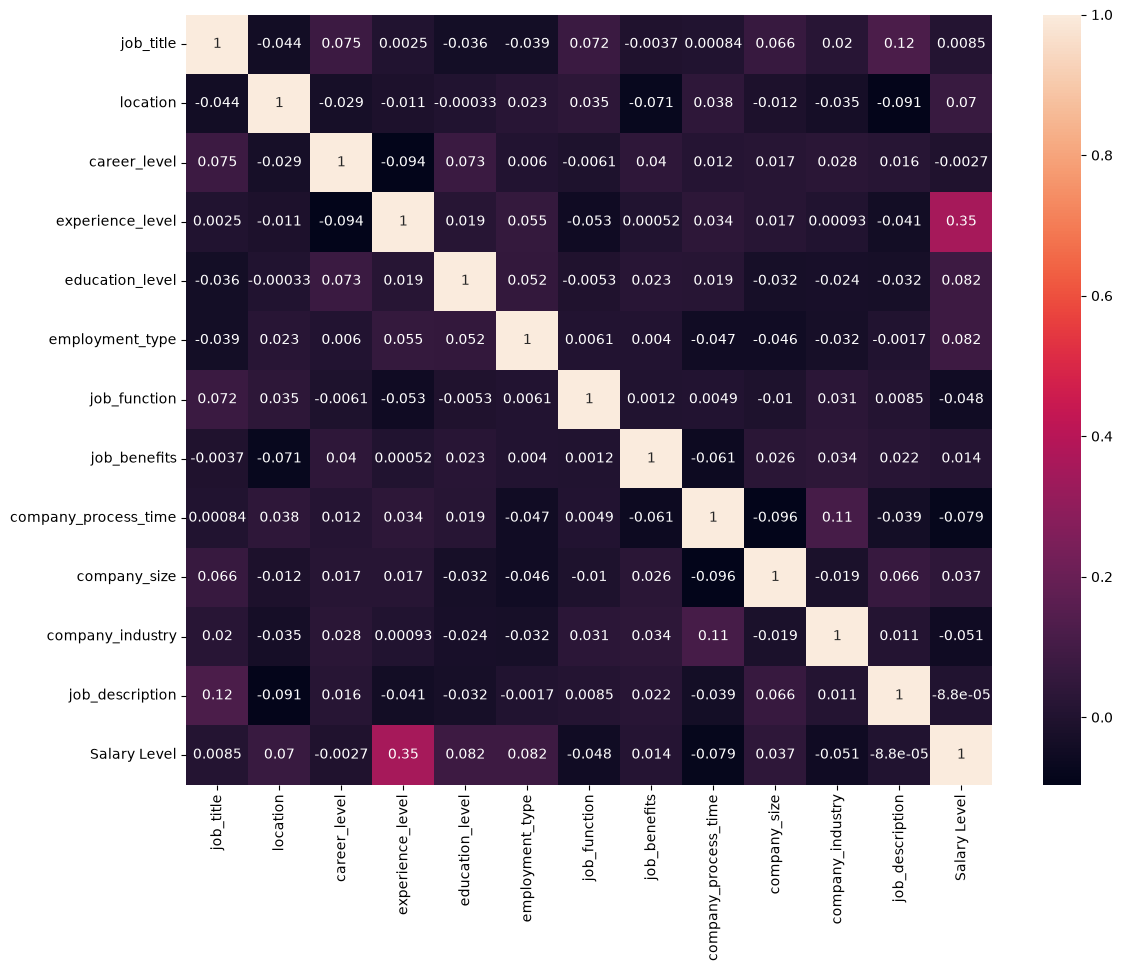

In [28]:
#finding the correlation using heat map
ax,fig = plt.subplots(figsize=(13, 10))
data = salarydf_copy2.corr()
sns.heatmap(data, annot=True)
plt.show()

__Explanation__:

The correlation between `Salary Level` and `job_title`, `job_benefits`, and `job_description` are very low so we will remove those 3 variables. We decided not to remove `career_level`, because we want to compare the `Salary Level` based on it.

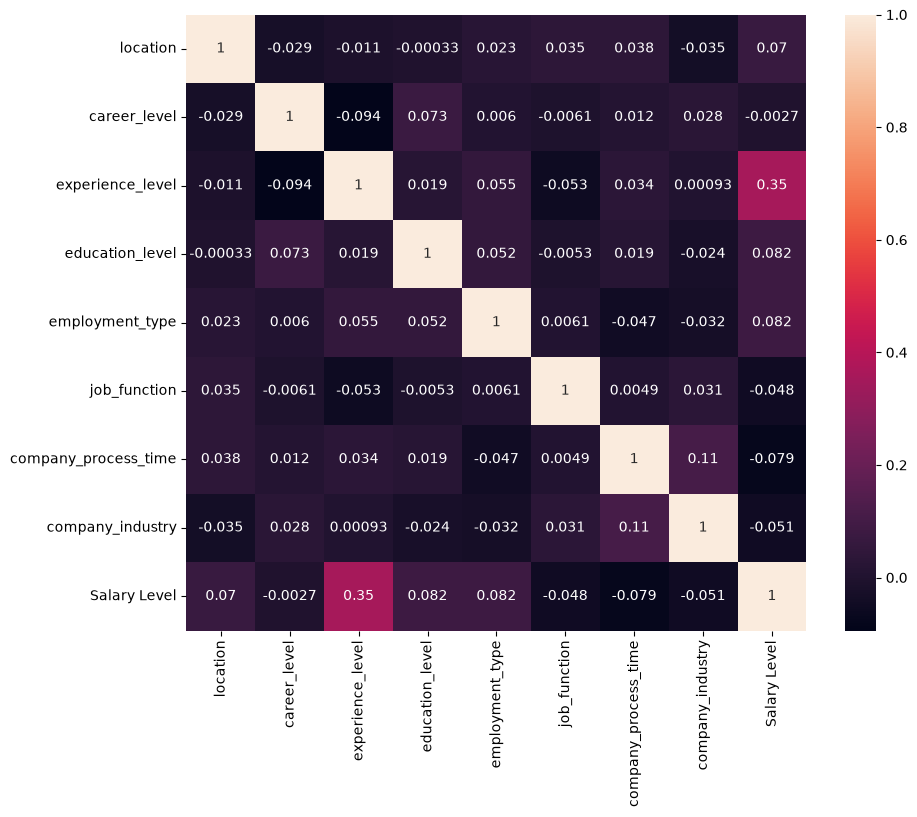

In [29]:
# Drop variables : job_title, job_benefits, job_description
salarydf_copy2 = salarydf_copy2.drop(['job_title', 'job_benefits', 'job_description', 'company_size'], axis = 1)

#finding the correlation using heat map
ax,fig = plt.subplots(figsize=(10, 8))
data = salarydf_copy2.corr()
sns.heatmap(data, annot=True)
plt.show()

__Explanation__:
- Correlations between one predictor to another are not high.
- Correlations between predictors and the target variable are not too high as well.
- Weak correlations might have happened due to imputation to the missing values, as they are not the actual sample value.

In [30]:
# Save the dataset to be used later
salarydf_copy2.to_csv('preprocessed_data.csv', index=False)